# Optional Project: Deep Learning with MNIST (Python)

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
(x_train, y_tr), (x_test, y_te) = mnist.load_data()

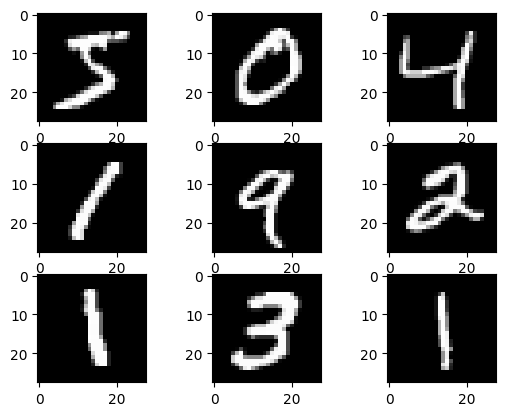

In [3]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
plt.show()


In [4]:
x_train = x_train.reshape(len(x_train), -1) / 255.
x_test = x_test.reshape(len(x_test), -1) / 255.

In [5]:
y_train = tf.keras.utils.to_categorical(y_tr, 10)
y_test = tf.keras.utils.to_categorical(y_te, 10)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Input

In [7]:
model = Sequential([
    Input((784,)),
    Dense(units = 128, activation='relu'),
    Dense(units = 10, activation='softmax')])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False), optimizer=tf.keras.optimizers.RMSprop(), metrics=['accuracy'])

In [9]:
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9184 - loss: 0.2847 - val_accuracy: 0.9548 - val_loss: 0.1592
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9615 - loss: 0.1325 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9719 - loss: 0.0927 - val_accuracy: 0.9703 - val_loss: 0.1090
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9786 - loss: 0.0729 - val_accuracy: 0.9715 - val_loss: 0.0986
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9823 - loss: 0.0608 - val_accuracy: 0.9707 - val_loss: 0.1049
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9854 - loss: 0.0506 - val_accuracy: 0.9733 - val_loss: 0.0967
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9879 - loss: 0.0428 - val_accuracy: 0.9753 - val_loss: 0.0990
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9892 - loss: 0.0363 - 

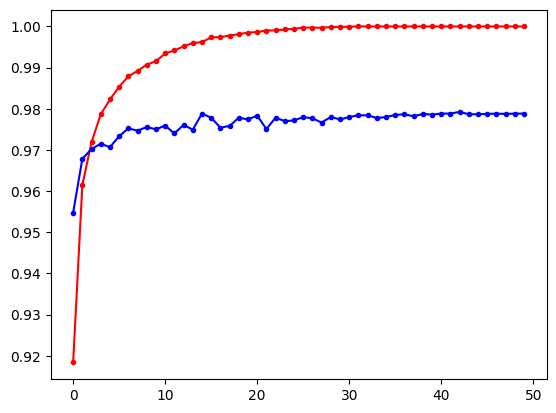

In [10]:
plt.plot(history.history['accuracy'],'r', marker='o', linestyle='-', markersize=3)
plt.plot(history.history['val_accuracy'],'b', marker='o', linestyle='-',  markersize=3)
plt.show()

In [14]:
model = Sequential([
    Input((784,)),
    Dense(units = 128, activation='relu'),
    Dropout(rate=0.3),
    Dense(units = 64, activation='relu'),
    Dropout(rate=0.2),
    Dense(units = 10, activation='softmax')])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False), optimizer=tf.keras.optimizers.RMSprop(), metrics=['accuracy'])

In [16]:
history = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8812 - loss: 0.4020 - val_accuracy: 0.9531 - val_loss: 0.1675
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9400 - loss: 0.2152 - val_accuracy: 0.9633 - val_loss: 0.1353
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9499 - loss: 0.1765 - val_accuracy: 0.9699 - val_loss: 0.1199
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9558 - loss: 0.1594 - val_accuracy: 0.9671 - val_loss: 0.1260
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9594 - loss: 0.1519 - val_accuracy: 0.9706 - val_loss: 0.1180
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9624 - loss: 0.1421 - val_accuracy: 0.9714 - val_loss: 0.1256
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9644 - loss: 0.1401 - val_accuracy: 0.9711 - val_loss: 0.1185
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9652 - loss: 0.1332 - 

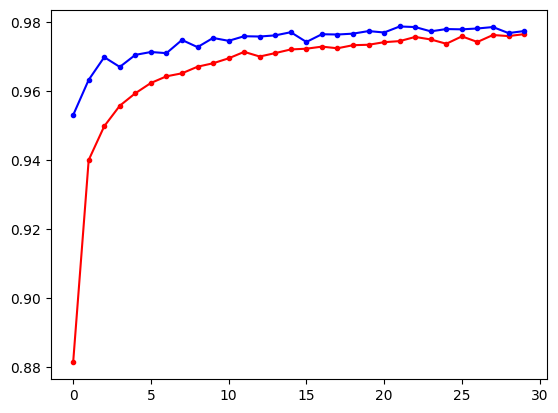

In [17]:
plt.plot(history.history['accuracy'],'r', marker='o', linestyle='-', markersize=3)
plt.plot(history.history['val_accuracy'],'b', marker='o', linestyle='-',  markersize=3)
plt.show()

In [18]:
model.evaluate(x_test, y_test) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.9765 - loss: 0.1606


[0.16057609021663666, 0.9764999747276306]

In [19]:
import numpy as np
pred = np.argmax(model.predict(x_train), axis=-1)
confusion_matrix = tf.math.confusion_matrix(labels=y_tr, predictions=pred)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step


In [20]:
confusion_matrix

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[5905,    0,    6,    0,    0,    1,    3,    1,    4,    3],
       [   1, 6718,    4,    3,    1,    0,    1,    9,    5,    0],
       [   6,   14, 5877,   13,    4,    0,    0,   27,   15,    2],
       [   1,    2,   16, 6049,    0,   17,    0,   15,   21,   10],
       [   1,   12,    3,    0, 5765,    1,    5,   10,    6,   39],
       [   9,    0,    4,   22,    3, 5337,   15,    9,   11,   11],
       [  17,    4,    2,    0,   15,    6, 5867,    0,    7,    0],
       [   2,   10,   10,    2,    0,    1,    0, 6233,    2,    5],
       [  11,   17,    7,   11,    1,   10,    1,    7, 5777,    9],
       [   9,    5,    0,   13,   11,    6,    0,   34,   10, 5861]])>

In [66]:
from PIL import Image

img_3 = np.array(Image.open("3.png"))
img_4 = np.array(Image.open("4.png"))
img_7 = np.array(Image.open("7.png"))

In [67]:
for r in img_4:
    for i in r:
        print(f"{i:<4}", end="")
    print()

0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   255 255 255 0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   255 255 0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   255 0   0   0   0   0   0   0   0   0   0   255 255 0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   255 0   0   0   0   0   0   0   0   0   0   255 255 0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   255 0   0   0   0   0   0   0   0   0   0   255 255 0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   255 0   0   0   0   0   0   0   0   0   0   255 255 0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   255 0   0   0   0   0   0   0   0   0   0   255 255 0   0   0   0   0   0   

In [68]:
img_3 = img_3.flatten()/255
img_4 = img_4.flatten()/255
img_7 = img_7.flatten()/255

In [69]:
np.argmax(model.predict(np.expand_dims(img_3, 0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


3

In [70]:
np.argmax(model.predict(np.expand_dims(img_4, 0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


4

In [72]:
np.argmax(model.predict(np.expand_dims(img_7, 0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


7

## What 3 techniques does the author of the tutorial use to reduce the potential overfitting found in the first run of the model?

The author creates a deeper network that can learn features better without overfitting. He also uses a dropout layer which prevents reliance on an overfitted neuron and allows for better learning. He finally reduces the number of epochs to stop the training process before it has time to overfit.

## What is a dropout layer and what is it used for here?

A dropout layer essentially randomly inhibits some neurons in a layer endering it useless. This decreases the reliance on a neuron that could be overfitted allowing for a model that is holistic.

## The model did not do well on the author's handwriting at first. Why was every number predicted as "5" (Ie. why not predicted as 0 or 6 or something else) by the model?

The model was probably extremely confused by the color switch so every possibility was equally unlikely. What probably happened was that the 5's in the training data had the most variability (i.e. there were a lot of different ways of writing 5 found in the training set), so the model learend to predict 5 when it was unsure. Since 5 could be written in a lot of ways, the model thought this was just another way of writing 5!

## What is the most frequently misclassified category of digit and how? (Ie. what digit is it in reality vs. what does the model classify it as?)

### a) In the tutorial

In the tutorial, it looks like 2 is the most misclassified and seems to be confused with 8 the most.

### b) In my model

In [97]:
np.sum(confusion_matrix, axis=-1)-np.diagonal(confusion_matrix)

array([18, 24, 81, 82, 77, 84, 51, 32, 74, 88])

In [103]:
confusion_matrix[9]

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([   9,    5,    0,   13,   11,    6,    0,   34,   10, 5861])>

It looks like the most misclassified digit was 9 which seems to be identified the most in the test set as 7! Interesting, but makes sense if the loop of the 9 isn't fully closed.

## Report your out of sample "validation" accuracy and comment on the difference between your test and training accuracies. What does the difference indicate for the goodness of your model?

accuracy: 0.9766

val_accuracy: 0.9775

test_accuracy: 0.9764

These accuracies are all super close to one another which is great! This means that the model did not overfit to the trainign set and generalizes well to data it has never seen before (like the images I tested on the model).

## Now create 6 images of digits with your tablet or track pad. Process the images according to the tutorial and predict their values using your trained with MNIST NN.  How accurate is the prediction of your own handwriting? Did you make it hard or easy for the trained model?

I did 3 above, so now I will do another 3 here!

In [109]:
img_1 = np.array(Image.open("1.png")).flatten()
img_2 = np.array(Image.open("2.png")).flatten()
img_8 = np.array(Image.open("8.png")).flatten()

In [110]:
np.argmax(model.predict(np.expand_dims(img_1, 0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


1

In [111]:
np.argmax(model.predict(np.expand_dims(img_2, 0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


2

In [112]:
np.argmax(model.predict(np.expand_dims(img_8, 0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


8

I did make it easy for the model, but I still think it did pretty well!